# 02. Baseline pentru extragerea biților din urme

Acest notebook fixează punctul de referință pentru etapa de învățare. Decoderul compară direct cele două ipoteze de bit, fără antrenare și fără parametri învățați.

La fiecare poziție construim ipoteza bit = 0 și ipoteza bit = 1, calculăm scurgerea așteptată în modelul HW sau HD și păstrăm varianta cu abaterea absolută mai mică.

## Problema decodării

Dacă prefixul estimat până la poziția $j-1$ este $p$, cele două ipoteze sunt:

$$
p_0 = 2p, \qquad p_1 = 2p + 1.
$$

Pentru HW comparăm `HW(p_0)` și `HW(p_1)` cu observația măsurată. Pentru HD folosim distanța Hamming față de prefixul anterior.

Baseline-ul arată câtă informație poate extrage un decoder determinist atunci când forma scurgerii este cunoscută.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "informatica").is_dir() and (p / "notebooks").is_dir()
)

ECDSA_DIR = PROJECT_ROOT / "informatica" / "ECDSA"
CNN_DIR = PROJECT_ROOT / "informatica" / "cnn"
ARTIFACTS_DIR = PROJECT_ROOT / "informatica" / "artifacts"
RESULTS_DIR = PROJECT_ROOT / "results"

for path in (ECDSA_DIR, CNN_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import json
import random
import statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataset_generator3 import CURVE, load_ground_truth
from ecdsa_leakage_model4 import (
    generate_clean_leakage,
    add_gaussian_noise,
    classify_bits,
    integer_to_bits,
    estimate_snr_db,
)

public_records = json.loads((ARTIFACTS_DIR / "public_dataset.json").read_text(encoding="utf-8"))
oracle = load_ground_truth(ARTIFACTS_DIR / "oracle_dataset.json")
truth_by_id = {int(k): v for k, v in oracle["samples"].items()}
profile_records = json.loads((ARTIFACTS_DIR / "profile_dataset.json").read_text(encoding="utf-8"))

width = CURVE.n.bit_length()
leaked_bits = 12

## Evaluare pe niveluri de zgomot

Pentru fiecare valoare de σ refacem aceeași familie de urme pornind de la nonce-urile controlate. Acuratețea pe bit măsoară proporția pozițiilor clasificate corect. Acuratețea de prefix cere ca toți cei 12 biți să fie corecți în aceeași semnătură.

In [3]:
def baseline_experiment(sigmas, sample_count=160, seed=20260919, mode="HW"):
    rows = []
    selected = public_records[:sample_count]

    for sigma in sigmas:
        rng = random.Random(seed)
        correct = 0
        total = 0
        prefix_correct = 0
        snr_values = []

        for record in selected:
            sample_id = int(record["sample_id"])
            nonce = int(truth_by_id[sample_id]["nonce_k"])
            actual = integer_to_bits(nonce, width)[:leaked_bits]
            clean = generate_clean_leakage(nonce, width, mode=mode, alpha=1.0)
            noisy = add_gaussian_noise(clean, sigma, rng)
            guesses = classify_bits(noisy, width, mode=mode, alpha=1.0)
            predicted = [bit for bit, _ in guesses][:leaked_bits]

            correct += sum(a == b for a, b in zip(actual, predicted))
            total += leaked_bits
            prefix_correct += int(predicted == actual)
            snr_values.append(estimate_snr_db(clean, sigma))

        rows.append({
            "sigma": float(sigma),
            "snr_db": float(statistics.fmean(snr_values)),
            "accuracy_bit": correct / total,
            "accuracy_prefix": prefix_correct / sample_count,
            "eșantioane": sample_count,
        })

    return pd.DataFrame(rows)

noise_table = baseline_experiment([0.15, 0.25, 0.50, 1.00, 1.50, 2.00, 3.00])
display(noise_table.style.format({
    "sigma": "{:.2f}",
    "snr_db": "{:.2f}",
    "accuracy_bit": "{:.4f}",
    "accuracy_prefix": "{:.4f}",
}))

,sigma,snr_db,accuracy_bit,accuracy_prefix,eșantioane
0,0.15,47.77,0.9979,0.9875,160
1,0.25,43.33,0.9594,0.7688,160
2,0.50,37.31,0.8031,0.2000,160
3,1.00,31.29,0.6609,0.0187,160
4,1.50,27.77,0.6177,0.0063,160
5,2.00,25.27,0.5953,0.0000,160
6,3.00,21.75,0.5714,0.0000,160


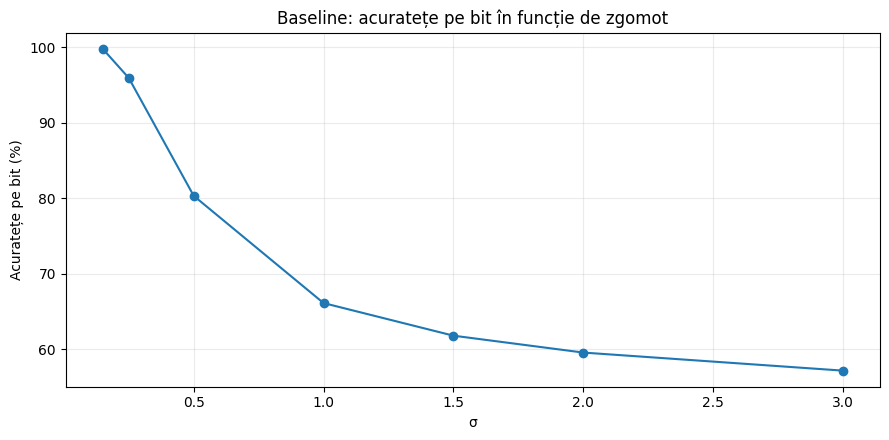

In [4]:
fig = plt.figure(figsize=(9, 4.5))
plt.plot(noise_table["sigma"], 100 * noise_table["accuracy_bit"], marker="o")
plt.xlabel("σ")
plt.ylabel("Acuratețe pe bit (%)")
plt.title("Baseline: acuratețe pe bit în funcție de zgomot")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

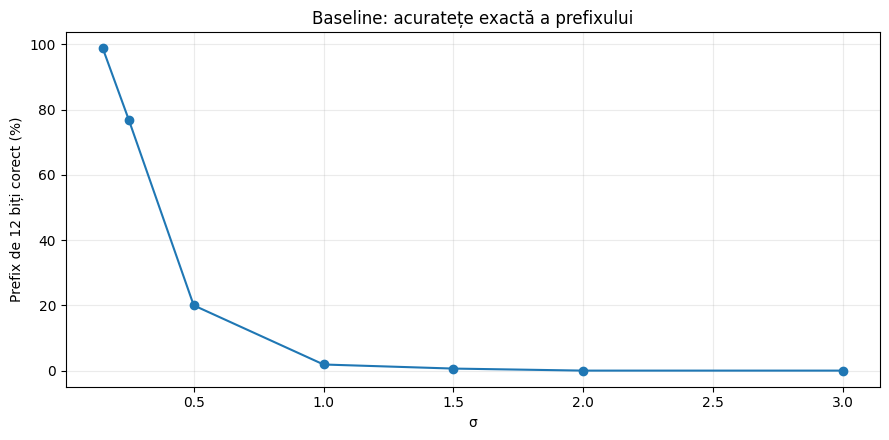

In [5]:
fig = plt.figure(figsize=(9, 4.5))
plt.plot(noise_table["sigma"], 100 * noise_table["accuracy_prefix"], marker="o")
plt.xlabel("σ")
plt.ylabel("Prefix de 12 biți corect (%)")
plt.title("Baseline: acuratețe exactă a prefixului")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Evaluarea setului profilat folosit de CNN

Setul generat anterior are σ = 0,15. Aici folosim exact urmele salvate și măsurăm numai primele 12 poziții, astfel încât baseline-ul și CNN-ul să fie comparabile.

In [6]:
correct = 0
total = 0
exact_prefix = 0

for record in profile_records:
    trace = list(map(float, record["trace"]))
    actual = list(map(int, record["bit_labels"][:leaked_bits]))
    predicted = [bit for bit, _ in classify_bits(trace, leaked_bits, mode="HW", alpha=1.0)]
    correct += sum(a == b for a, b in zip(actual, predicted))
    total += leaked_bits
    exact_prefix += int(predicted == actual)

fixed_profile_metrics = {
    "sigma": 0.15,
    "bit_accuracy": correct / total,
    "prefix_accuracy": exact_prefix / len(profile_records),
    "samples": len(profile_records),
    "leaked_bits": leaked_bits,
}

display(pd.DataFrame([fixed_profile_metrics]).T.rename(columns={0: "valoare"}))

,valoare
sigma,0.150000
bit_accuracy,0.997917
prefix_accuracy,0.987500
samples,160.000000
leaked_bits,12.000000


## Interpretare experimentală

Acuratețea pe bit și acuratețea de prefix măsoară lucruri diferite. Prima privește pozițiile separat. A doua cere ca toate cele 12 predicții să fie corecte.

Pentru etapa HNP, diferența contează deoarece un prefix greșit schimbă valoarea $a_i$ și, odată cu ea, constrângerea modulară transmisă solverului.

In [7]:
baseline_results = {
    "noise_sweep": noise_table.to_dict(orient="records"),
    "fixed_profile": fixed_profile_metrics,
    "mode": "HW",
    "leaked_bits": leaked_bits,
    "seed": 20260919,
}

(ARTIFACTS_DIR / "baseline_results.json").write_text(
    json.dumps(baseline_results, indent=2),
    encoding="utf-8",
)

print("Rezultatele baseline au fost salvate în informatca/artifacts/baseline_results.json".replace("informatca", "informatica"))

Rezultatele baseline au fost salvate în informatica/artifacts/baseline_results.json


## Referințe

- Modelul HW/HD și experimentul cu zgomot: `informatica/ECDSA/ecdsa_leakage_model4.py`.
- J. Breitner și N. Heninger, [Biased Nonce Sense](https://dblp.org/rec/conf/fc/BreitnerH19.html), Financial Cryptography 2019.